In [1]:
import numpy as np
import matplotlib.pyplot as plt

Параметры: R = 16.666 Ом, C = 1e-06 Ф, Rг = 50 Ом
s(0 Гц) = -0.500015
s(∞) → -1


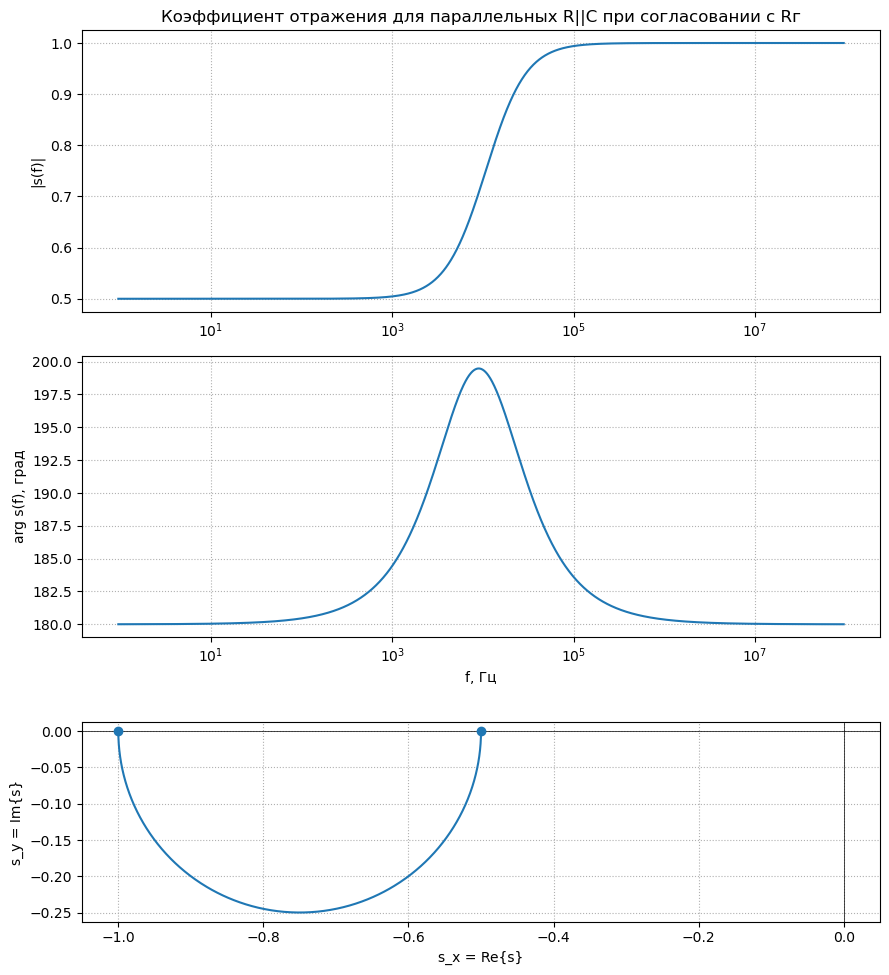

In [2]:
R_g = 50.0
R = 16.666
C = 1e-6

fc = 1.0 / (2.0 * np.pi * R * C)
f1 = max(fc / 1e4, 1e-3)
f2 = min(fc * 1e4, 1e12)

f_log = np.logspace(np.log10(f1), np.log10(f2), 2000)
f = np.concatenate(([0.0], f_log))

w = 2.0 * np.pi * f
Y = 1.0 / R + 1j * w * C
Z = 1.0 / Y
s = (Z - R_g) / (Z + R_g)
s_mag = np.abs(s)
s_phase = np.unwrap(np.angle(s)) * 180.0 / np.pi
s_re, s_im = s.real, s.imag

s_dc = (R - R_g) / (R + R_g)

print(f"Параметры: R = {R:.6g} Ом, C = {C:.6g} Ф, Rг = {R_g:.6g} Ом")
print(f"s(0 Гц) = {s_dc:.6g}")
print("s(∞) → -1")

plt.figure(figsize=(9, 10))

plt.subplot(3, 1, 1)
plt.semilogx(f_log, s_mag[1:], lw=1.5)
plt.grid(True, which='both', ls=':')
plt.ylabel('|s(f)|')
plt.title('Коэффициент отражения для параллельных R||C при согласовании с Rг')

plt.subplot(3, 1, 2)
plt.semilogx(f_log, s_phase[1:], lw=1.5)
plt.grid(True, which='both', ls=':')
plt.ylabel('arg s(f), град')
plt.xlabel('f, Гц')

plt.subplot(3, 1, 3)
plt.plot(s_re, s_im, lw=1.5)
plt.scatter([s_re[0], s_re[-1]], [s_im[0], s_im[-1]], marker='o', zorder=3)
plt.axhline(0, color='k', lw=0.5)
plt.axvline(0, color='k', lw=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, ls=':')
plt.xlabel('s_x = Re{s}')
plt.ylabel('s_y = Im{s}')

plt.tight_layout()
plt.show()

Параметры: R = 150 Ом, L = 0.0001 Гн, Rг = 50 Ом
s(0 Гц) = 0.5
s(∞) → 1


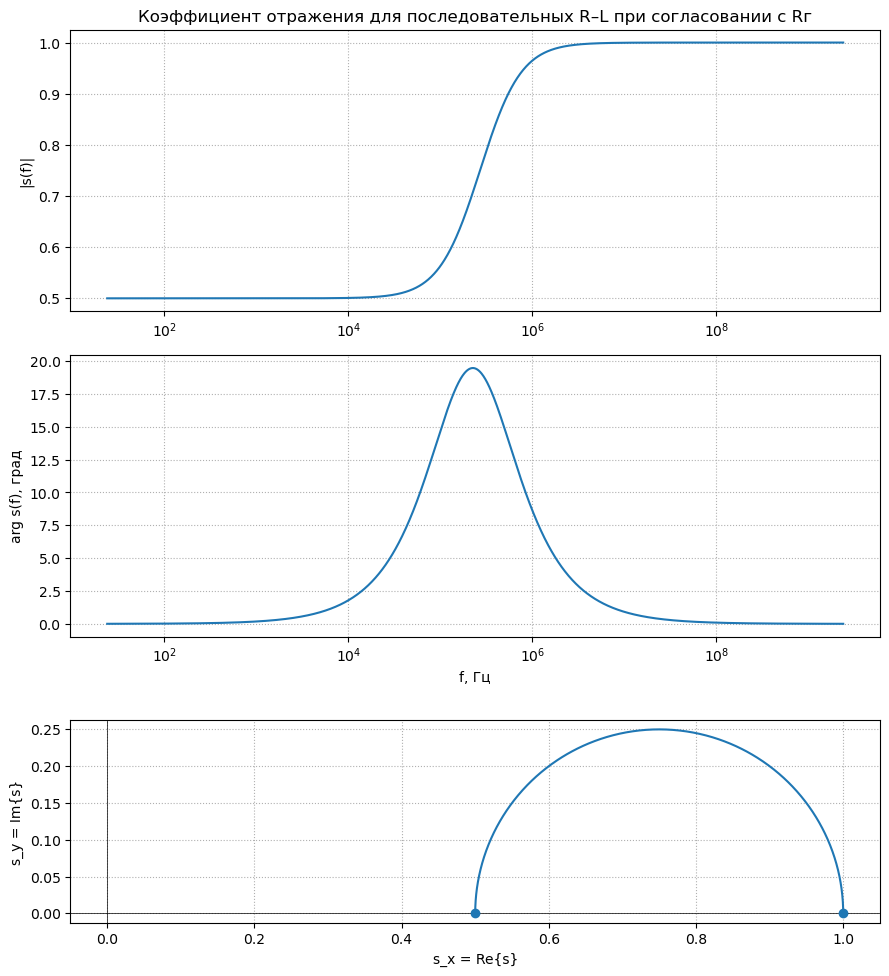

In [ ]:
R_g = 50.0
R = 150.0
L = 100e-6

fc = R / (2.0 * np.pi * L) # Частота, где ωL = R
f1 = max(fc / 1e4, 1e-3) # Нижняя граница частот
f2 = min(fc * 1e4, 1e12) # Верхняя граница частот

f_log = np.logspace(np.log10(f1), np.log10(f2), 2000)  # Логарифмическая шкала частот
f = np.concatenate(([0.0], f_log))  # Добавляем нулевую частоту

w = 2.0 * np.pi * f # Угловая частота
Z = R + 1j * w * L # Полный импеданс цепи R-L
s = (Z - R_g) / (Z + R_g)  # Коэффициент отражения
s_mag = np.abs(s)  # Амплитуда коэффициента отражения 
s_phase = np.unwrap(np.angle(s)) * 180.0 / np.pi # Фаза в градусах
s_re, s_im = s.real, s.imag # Действительная и мнимая части
 
s_dc = (R - R_g) / (R + R_g)

print(f"Параметры: R = {R:.6g} Ом, L = {L:.6g} Гн, Rг = {R_g:.6g} Ом")
print(f"s(0 Гц) = {s_dc:.6g}")
print("s(∞) → 1")

plt.figure(figsize=(9, 10))

plt.subplot(3, 1, 1)
plt.semilogx(f_log, s_mag[1:], lw=1.5)
plt.grid(True, which='both', ls=':')
plt.ylabel('|s(f)|')
plt.title('Коэффициент отражения для последовательных R–L при согласовании с Rг')

plt.subplot(3, 1, 2)
plt.semilogx(f_log, s_phase[1:], lw=1.5)
plt.grid(True, which='both', ls=':')
plt.ylabel('arg s(f), град')
plt.xlabel('f, Гц')

plt.subplot(3, 1, 3)
plt.plot(s_re, s_im, lw=1.5)
plt.scatter([s_re[0], s_re[-1]], [s_im[0], s_im[-1]], marker='o', zorder=3)
plt.axhline(0, color='k', lw=0.5)
plt.axvline(0, color='k', lw=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, ls=':')
plt.xlabel('s_x = Re{s}')
plt.ylabel('s_y = Im{s}')

plt.tight_layout()
plt.show()